In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import numpy as np

import config
from config import THICKNESS_VALUES, RAYLEIGH_ALPHA, RAYLEIGH_BETA


from beam_element import element_stiffness, element_mass, compute_section_properties
from assembly import generate_mesh, assemble_global_matrices, apply_boundary_conditions
from damping import build_rayleigh_damping, rayleigh_from_damping_ratios
from materials import get_material, list_materials, add_material


In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import os
from importlib import reload

import sampling
reload(sampling)
from sampling      import generate_parameter_sets
from batch_runner  import run_batch
from exporter      import export_all_simulations, export_time_vector
from config        import DT, N_STEPS, EXPORT_MODE

# =============================================================
# CONFIGURATION
# =============================================================
OUTPUT_DIR    = 'simulation_results'   # folder for all CSV files
N_JOBS        = -1                     # -1 = use all CPU cores
SAMPLING_MODE = 1                      # 1 = discrete, 2 = continuous
ENCODING      = 'C'                    # A = serialized string per node (2 rows)
                                       # B = one column per node per timestep (2 rows, very wide)
                                       # C = one row per timestep, 2000 rows x 101 node cols

# =============================================================
# STEP 1 — GENERATE PARAMETER SETS
# =============================================================
print("=" * 60)
print(" STEP 1 — Generating parameter sets")
print("=" * 60)

param_sets = generate_parameter_sets(mode=SAMPLING_MODE)

print(f"  Parameter sets ready  : {len(param_sets)}")
print()
print("  Sample of first 5 simulations:")
for p in param_sets[:5]:
    freq_str = f"{p['excitation_freq']:.0f} Hz" if p['excitation_freq'] else "N/A"
    print(f"    sim {p['sim_id']:04d} | "
          f"{p['bc_type']:<20} | "
          f"{p['material']:<10} | "
          f"L={p['length_in']:5.0f} in | "
          f"b={p['width_in']:.1f} in | "
          f"F0={p['impact_F0_lbf']:5.0f} lbf | "
          f"{p['loading_type']:<8} | "
          f"pos={p['impact_position']:.2f} | "
          f"freq={freq_str} | "
          f"SNR={p['snr_db']} dB")
print()

# =============================================================
# STEP 2 — RUN FULL BATCH IN PARALLEL
# =============================================================
print("=" * 60)
print(" STEP 2 — Running simulations in parallel")
print("=" * 60)
print(f"  Total simulations : {len(param_sets)}")
print(f"  CPU cores         : {N_JOBS} (-1 = all available)")
print()

start_time = time.time()

results, n_success, n_failed = run_batch(param_sets, n_jobs=N_JOBS)

elapsed      = time.time() - start_time
time_per_sim = elapsed / len(param_sets)

print()
print(f"  Total time        : {round(elapsed, 2)} s  "
      f"({round(elapsed/60, 2)} min)")
print(f"  Time per sim      : {round(time_per_sim, 3)} s")
print(f"  Succeeded         : {n_success}")
print(f"  Failed            : {n_failed}")
print()

# =============================================================
# STEP 3 — EXPORT ONE CSV PER SIMULATION
# =============================================================
print("=" * 60)
print(f" STEP 3 — Exporting CSVs (mode: {EXPORT_MODE})")
print("=" * 60)

file_paths, n_exported, n_skipped = export_all_simulations(
    results,
    output_dir  = OUTPUT_DIR,
    encoding    = ENCODING,
    export_mode = EXPORT_MODE
)

print()
export_time_vector(output_dir=OUTPUT_DIR)

# =============================================================
# STEP 4 — Summary statistics
# =============================================================
print()
print("=" * 60)
print(" STEP 4 — Summary statistics")
print("=" * 60)
print(f"  Total simulations  : {len(results)}")
print(f"  Succeeded          : {n_success}")
print(f"  Failed             : {n_failed}")
print(f"  Sims exported      : {n_exported}")
print(f"  Files written      : {len(file_paths)}")
print(f"  Export mode        : {EXPORT_MODE}")
print(f"  Output folder      : {os.path.abspath(OUTPUT_DIR)}")
print()

bc_types       = [r['params']['bc_type']        for r in results if r['status'] == 'success']
materials      = [r['params']['material']        for r in results if r['status'] == 'success']
lengths        = [r['params']['length_in']       for r in results if r['status'] == 'success']
widths         = [r['params']['width_in']        for r in results if r['status'] == 'success']
forces         = [r['params']['impact_F0_lbf']   for r in results if r['status'] == 'success']
loading_types  = [r['params']['loading_type']    for r in results if r['status'] == 'success']
positions      = [r['params']['impact_position'] for r in results if r['status'] == 'success']
snr_values     = [r['params']['snr_db']          for r in results if r['status'] == 'success']

print("  Boundary condition distribution:")
for bc in sorted(set(bc_types)):
    count = bc_types.count(bc)
    print(f"    {bc:<20} : {count} simulations")
print()

print("  Loading type distribution:")
for lt in sorted(set(loading_types)):
    count = loading_types.count(lt)
    print(f"    {lt:<12} : {count} simulations")
print()

print("  SNR distribution:")
for snr in sorted(set(snr_values)):
    count = snr_values.count(snr)
    print(f"    SNR = {snr:3.0f} dB   : {count} simulations")
print()

print("  Impact position distribution:")
for pos in sorted(set(positions)):
    count = positions.count(pos)
    print(f"    pos = {pos:.2f}     : {count} simulations")
print()

print("  Material distribution:")
for mat in sorted(set(materials)):
    count = materials.count(mat)
    print(f"    {mat:<12} : {count} simulations")
print()

print("  Length distribution:")
for L in sorted(set(lengths)):
    count = lengths.count(L)
    print(f"    L = {L:5.0f} in  : {count} simulations")
print()

print("  Width distribution:")
for b in sorted(set(widths)):
    count = widths.count(b)
    print(f"    b = {b:.1f} in    : {count} simulations")
print()

print("  Force distribution:")
for F in sorted(set(forces)):
    count = forces.count(F)
    print(f"    F0 = {F:6.0f} lbf : {count} simulations")
print()

r0 = next(r for r in results if r['status'] == 'success')
print("  Example simulation (first success):")
for k, v in r0['params'].items():
    print(f"    {k:<20} : {v}")

# =============================================================
# STEP 5 — Plotting sample simulation (one per loading type)
# =============================================================
print()
print("=" * 60)
print(" STEP 5 — Plotting sample simulations (one per loading type)")
print("=" * 60)

def get_plot_node(bc_type):
    """
    Pick the best node index for plotting based on BC type.
    Avoids fixed supports where acceleration is always zero.
      cantilever       : tip  (node 100) — free end
      simply_supported : mid  (node 50)  — max displacement
      fixed_fixed      : mid  (node 50)  — max displacement
    """
    if bc_type == 'cantilever':
        return 100, "Tip Node (Node 101)"
    else:
        return 50, "Mid Node (Node 51)"

loading_type_list = sorted(set(loading_types))
time_vector       = np.linspace(0, DT * (N_STEPS - 1), N_STEPS)

for lt in loading_type_list:
    # Find first successful result for this loading type
    r_lt = next((r for r in results
                 if r['status'] == 'success' and r['params']['loading_type'] == lt), None)
    if r_lt is None:
        print(f"  No successful simulations for {lt}, skipping.")
        continue

    node_accels  = r_lt['node_accels']
    noisy_accels = r_lt.get('noisy_accels', node_accels)
    p            = r_lt['params']
    lt_label     = lt.replace('_', ' ').title()
    bc_label     = p['bc_type'].replace('_', ' ').title()

    freq_str = f" | f_exc = {p['excitation_freq']:.0f} Hz" if p['excitation_freq'] else ""

    # Pick a node that actually moves for this BC type
    plot_node, node_label = get_plot_node(p['bc_type'])

    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

    fig.suptitle(
        f"Beam Vibration — Transverse Acceleration at {node_label}\n"
        f"{lt_label} Loading | {bc_label} | {p['material'].capitalize()} | "
        f"L = {p['length_in']:.0f} in | b = {p['width_in']:.1f} in | "
        f"t = {p['thickness_in']:.2f} in | F0 = {p['impact_F0_lbf']:.0f} lbf | "
        f"pos = {p['impact_position']:.2f}{freq_str} | "
        f"SNR = {p['snr_db']} dB",
        fontsize=12
    )

    # Plot 1: Clean signal
    axes[0].plot(time_vector, node_accels[plot_node, :],
                 color='tab:blue', linewidth=0.7)
    axes[0].set_title(f"Clean Signal ({node_label})")
    axes[0].set_ylabel("Accel (in/s²)")
    axes[0].grid(True, alpha=0.3)

    # Plot 2: Noisy signal
    axes[1].plot(time_vector, noisy_accels[plot_node, :],
                 color='tab:orange', linewidth=0.7)
    axes[1].set_title(f"Noisy Signal (SNR = {p['snr_db']} dB)")
    axes[1].set_ylabel("Accel (in/s²)")
    axes[1].grid(True, alpha=0.3)

    # Plot 3: Overlay
    axes[2].plot(time_vector, node_accels[plot_node, :],
                 color='tab:blue', linewidth=0.7, label='Clean', alpha=0.7)
    axes[2].plot(time_vector, noisy_accels[plot_node, :],
                 color='tab:orange', linewidth=0.5, label='Noisy', alpha=0.5)
    axes[2].set_title("Clean vs Noisy Overlay")
    axes[2].set_ylabel("Accel (in/s²)")
    axes[2].legend(loc='upper right')
    axes[2].grid(True, alpha=0.3)

    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()

    plot_name = f'sample_{lt}.png'
    plot_path = os.path.join(OUTPUT_DIR, plot_name)
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  [{lt_label}] Plot saved to: {plot_path}")

# =============================================================
# STEP 6 — FINAL FILE SUMMARY
# =============================================================
print()
print("=" * 60)
print(" STEP 6 — Output files")
print("=" * 60)
print(f"  Location    : {os.path.abspath(OUTPUT_DIR)}")
print(f"  Export mode : {EXPORT_MODE}")
print()
print("  Files created:")
if EXPORT_MODE in ('clean', 'both'):
    print(f"    sim_0000.csv to sim_{n_exported-1:04d}.csv  (clean)")
if EXPORT_MODE in ('noisy', 'both'):
    print(f"    sim_0000_noisy.csv to sim_{n_exported-1:04d}_noisy.csv  (noisy)")
print(f"    time_vector.csv")
for lt in loading_type_list:
    print(f"    sample_{lt}.png")
print()
if ENCODING == 'C':
    print("  Each CSV contains (Encoding C):")
    print(f"    - {N_STEPS} rows (one per timestep)")
    print(f"    - 22 metadata columns repeated on every row")
    print(f"      (incl. bc_type, loading_type, impact_position, excitation_freq, snr_db)")
    print(f"    - time_s column")
    print(f"    - 101 node columns (node_001_accel to node_101_accel)")
elif ENCODING == 'A':
    print("  Each CSV contains (Encoding A):")
    print(f"    - 1 row")
    print(f"    - 22 metadata columns")
    print(f"      (incl. bc_type, loading_type, impact_position, excitation_freq, snr_db)")
    print(f"    - 101 node columns (node_001_accel to node_101_accel)")
    print(f"    - Each node column = {N_STEPS} acceleration values")
    print(f"      serialized as ';' delimited string")
print()
print("=" * 60)
print(" PIPELINE COMPLETE")
print("=" * 60)

 BEAM VIBRATION VISUALIZATION
Loaded  : sim_0001.csv
  Material   : steel
  Length     : 50.0 in
  Width      : 2.0 in
  Force      : 5.0 lbf
  n_nodes    : 101
  n_steps    : 2000
  dt         : 0.0005002501250625 s
  f_nyquist  : 999.5 Hz

  Frequency range : 1 Hz to 999.5 Hz
  X-axis scale    : log
  Y-axis scale    : linear

[1/6] Plotting time history...
Time history plot saved: simulation_results/plots\sim_0001_time_history.png


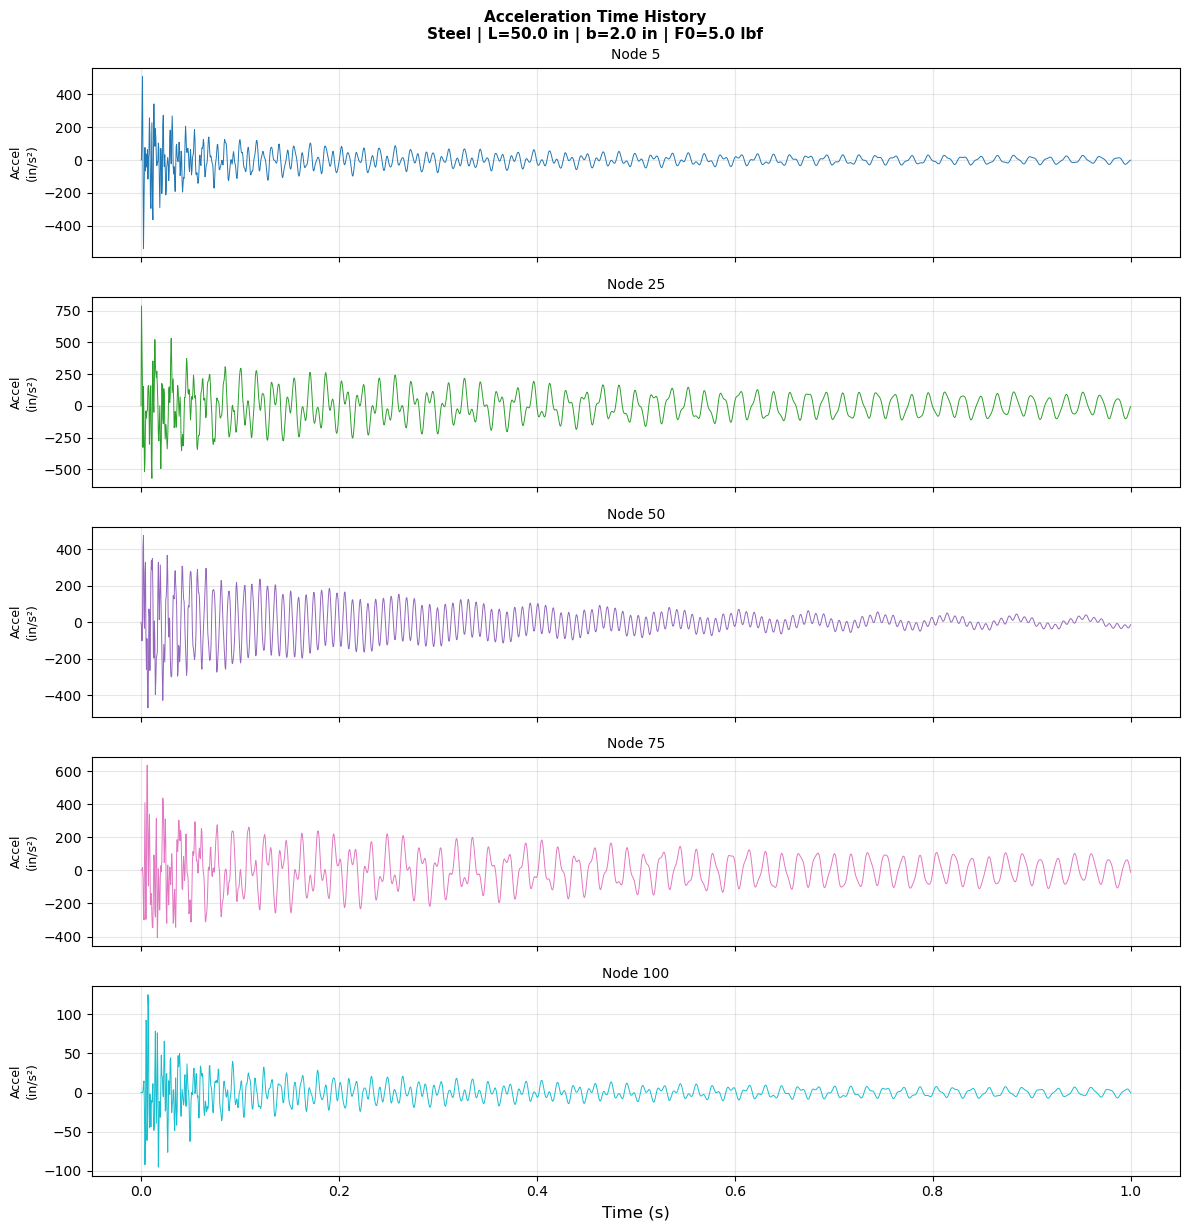


[2/6] Computing and plotting FFT...
FFT plot saved: simulation_results/plots\sim_0001_fft.png


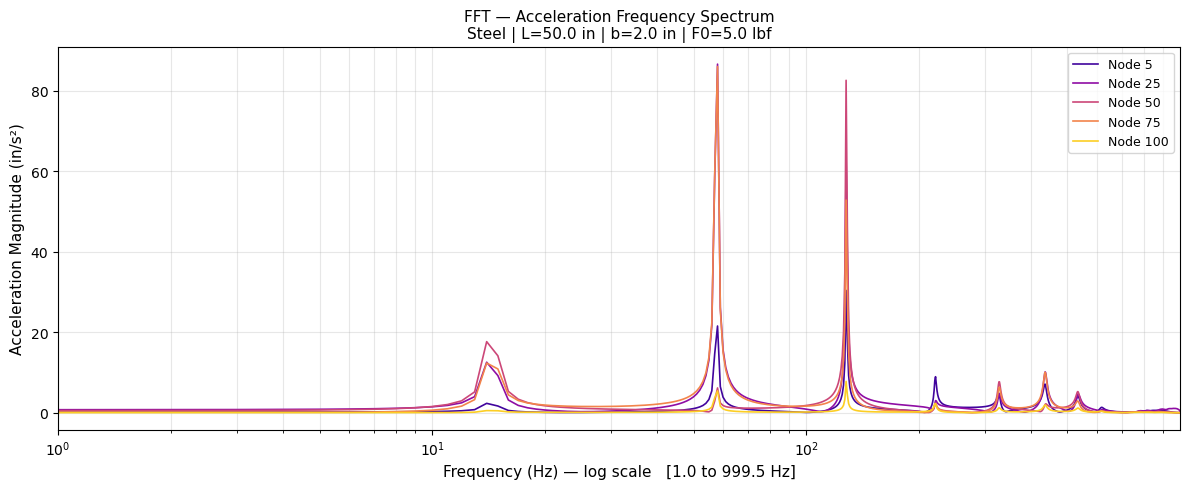


[3/6] Plotting FFT waterfall...
Waterfall plot saved: simulation_results/plots\sim_0001_fft_waterfall.png


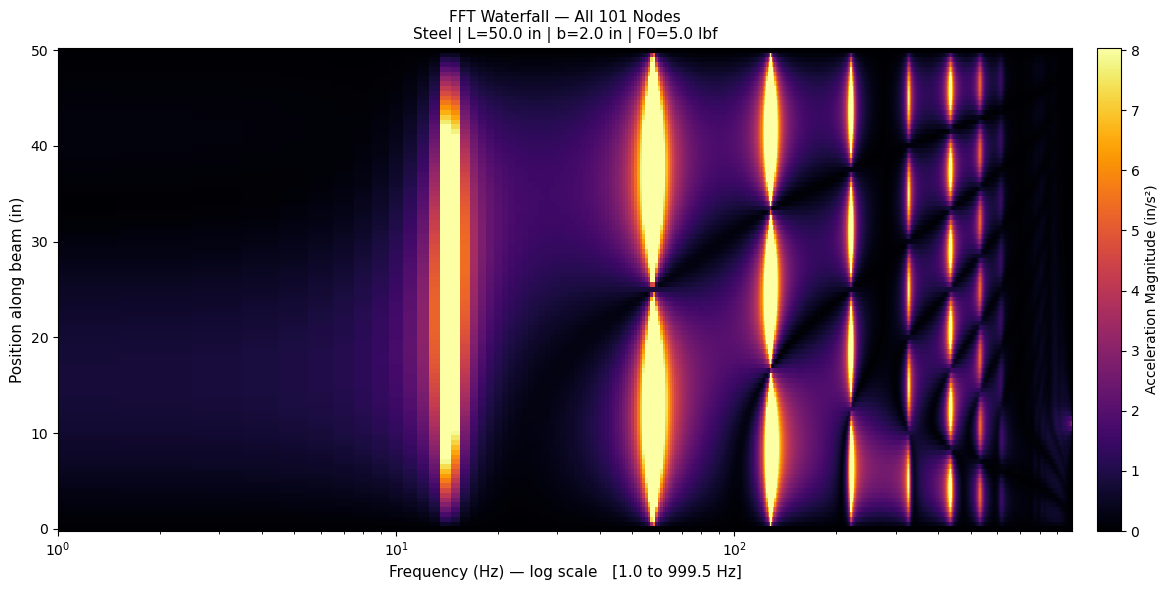


[4/6] Computing and plotting FRF...
FRF plot saved: simulation_results/plots\sim_0001_frf.png


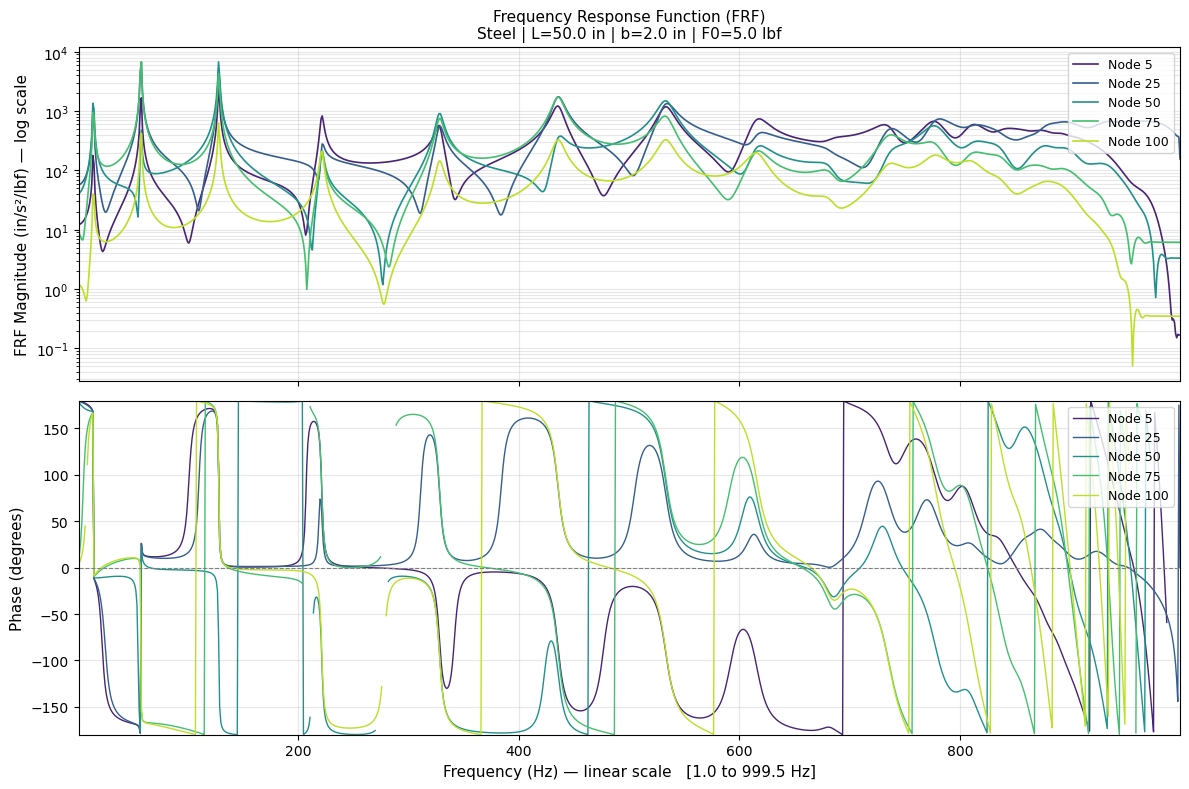


[5/6] Plotting per-node FRF and phase (600 Hz)...
Per-node FRF plot saved: simulation_results/plots\sim_0001_frf_per_node.png


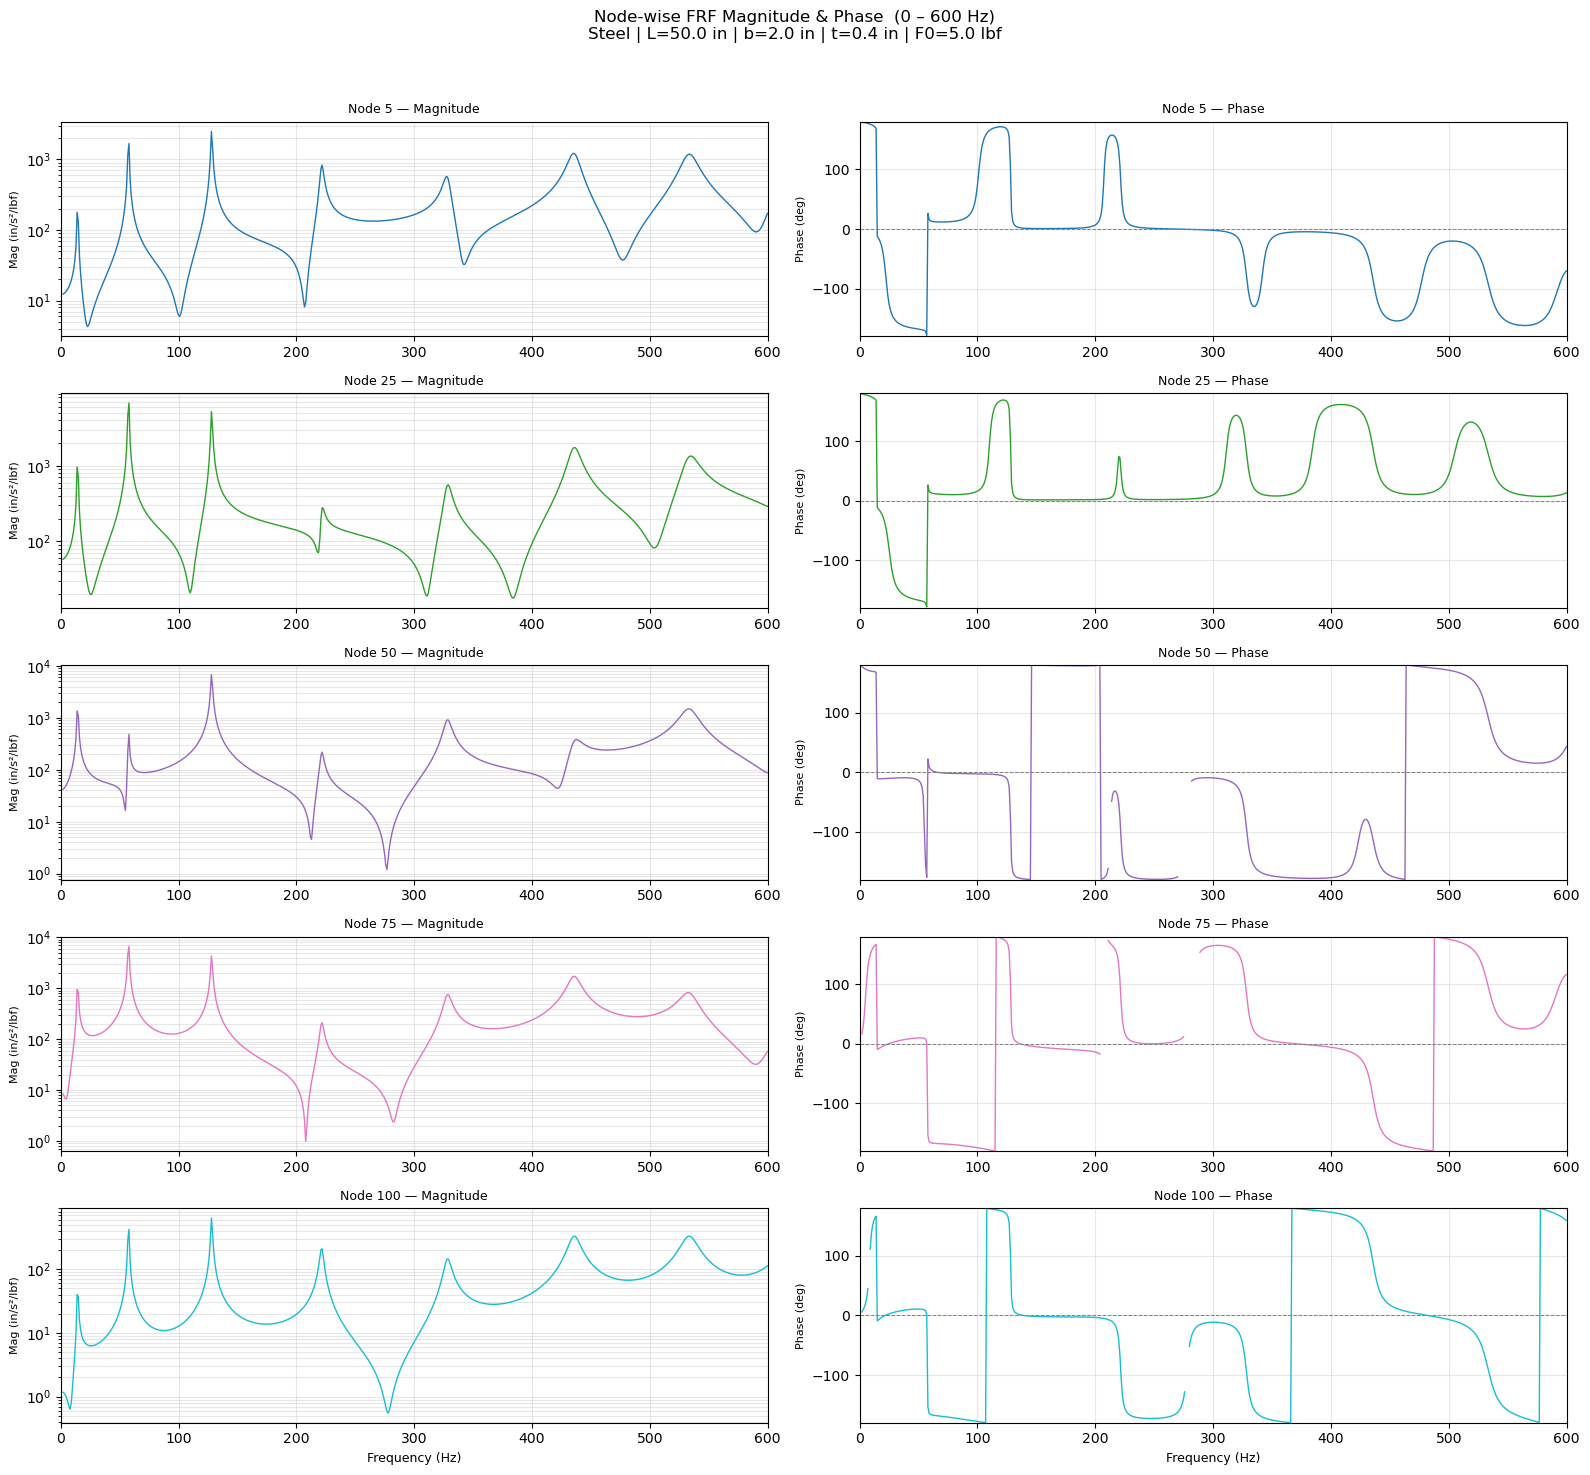


[6/6] Computing exact mode shapes via eigenvalue analysis...

Eigenvalue-based natural frequencies (all modes of structure):
  Mode 1: 14.43 Hz
  Mode 2: 57.72 Hz
  Mode 3: 129.88 Hz
  Mode 4: 230.9 Hz
  Mode 5: 360.78 Hz
  Mode 6: 519.52 Hz

  NOTE  (simply_supported): Force is applied at midspan.
  Even-numbered modes (2, 4, 6, ...) have a displacement node at
  midspan and CANNOT be excited. They will appear in eigenvalue
  analysis but NOT as peaks in the FRF or FFT.
  Only ODD modes will show as FRF peaks:
    Mode 1: 14.43 Hz  ← visible in FRF
    Mode 3: 129.88 Hz  ← visible in FRF
    Mode 5: 360.78 Hz  ← visible in FRF
Mode shape plot saved: simulation_results/plots\sim_0001_mode_shapes.png


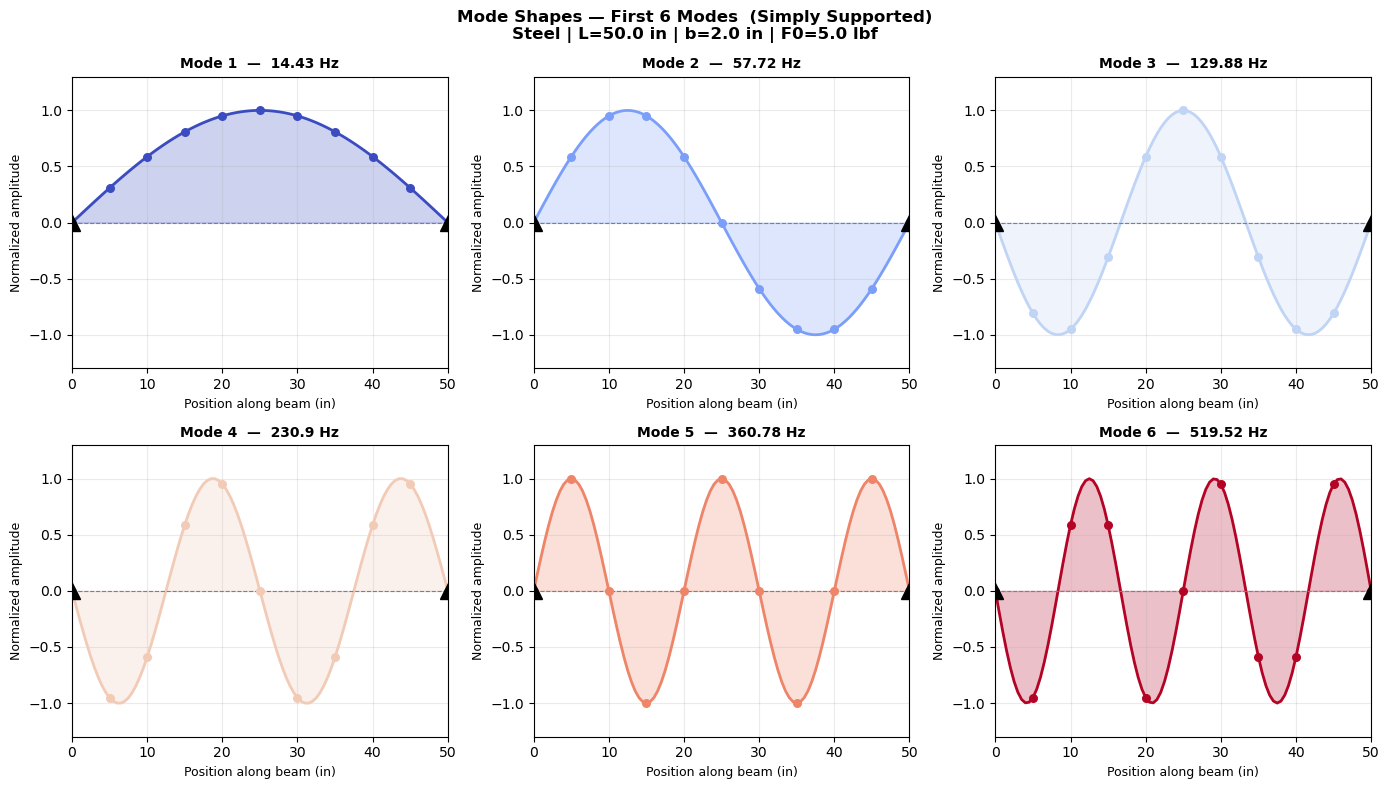


 VISUALIZATION COMPLETE  (6 plots)
 Plots saved to: c:\Users\G_Modak\Desktop\PhD work\Trial 26 Feb 2026 _Cantilever, Simply_supported and fixed to fixed end\simulation_results\plots


In [2]:
from importlib import reload
import visualization
reload(visualization)
from visualization import run_visualization



# Pick any sim CSV — bc_type is auto-read from the CSV metadata.
# Examples:
#   sim_0000.csv  (random BC from the shuffle)
#   sim_1000.csv  etc.
run_visualization(
    csv_file_path = 'simulation_results/sim_0001.csv',
    output_dir    = 'simulation_results/plots',
    n_modes       = 6,
    nodes_to_plot = [4, 24, 49, 74, 99]   # Node 5, 25, 50, 75, 100 (1-indexed)
)
